In [1]:
# Quantium Virtual Internship - Task 1
# Data Cleaning and Analysis
# By: Mercy Ogbonna

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("Libraries loaded successfully!")

Libraries loaded successfully!


In [3]:
import os
print(os.getcwd())

C:\Users\konge


In [8]:
transaction = pd.read_excel("QVI_transaction_data (1).xlsx")
customer = pd.read_csv("QVI_purchase_behaviour.csv")

print("Transaction data shape:", transaction.shape)
print("Customer data shape:", customer.shape)

Transaction data shape: (264836, 8)
Customer data shape: (72637, 3)


In [9]:
print(transaction.shape)
print(customer.shape)

(264836, 8)
(72637, 3)


In [10]:
# Look at the first 5 rows of transaction data
print("=== TRANSACTION DATA - FIRST 5 ROWS ===")
print(transaction.head())

print("\n=== CUSTOMER DATA - FIRST 5 ROWS ===")
print(customer.head())

=== TRANSACTION DATA - FIRST 5 ROWS ===
    DATE  STORE_NBR  LYLTY_CARD_NBR  TXN_ID  PROD_NBR  \
0  43390          1            1000       1         5   
1  43599          1            1307     348        66   
2  43605          1            1343     383        61   
3  43329          2            2373     974        69   
4  43330          2            2426    1038       108   

                                  PROD_NAME  PROD_QTY  TOT_SALES  
0    Natural Chip        Compny SeaSalt175g         2        6.0  
1                  CCs Nacho Cheese    175g         3        6.3  
2    Smiths Crinkle Cut  Chips Chicken 170g         2        2.9  
3    Smiths Chip Thinly  S/Cream&Onion 175g         5       15.0  
4  Kettle Tortilla ChpsHny&Jlpno Chili 150g         3       13.8  

=== CUSTOMER DATA - FIRST 5 ROWS ===
   LYLTY_CARD_NBR               LIFESTAGE PREMIUM_CUSTOMER
0            1000   YOUNG SINGLES/COUPLES          Premium
1            1002   YOUNG SINGLES/COUPLES       Mainstream


In [11]:
# Check data types and missing values
print("=== TRANSACTION DATA INFO ===")
print(transaction.info())

print("\n=== CUSTOMER DATA INFO ===")
print(customer.info())

=== TRANSACTION DATA INFO ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 264836 entries, 0 to 264835
Data columns (total 8 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   DATE            264836 non-null  int64  
 1   STORE_NBR       264836 non-null  int64  
 2   LYLTY_CARD_NBR  264836 non-null  int64  
 3   TXN_ID          264836 non-null  int64  
 4   PROD_NBR        264836 non-null  int64  
 5   PROD_NAME       264836 non-null  object 
 6   PROD_QTY        264836 non-null  int64  
 7   TOT_SALES       264836 non-null  float64
dtypes: float64(1), int64(6), object(1)
memory usage: 16.2+ MB
None

=== CUSTOMER DATA INFO ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 72637 entries, 0 to 72636
Data columns (total 3 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   LYLTY_CARD_NBR    72637 non-null  int64 
 1   LIFESTAGE         72637 non-null  object
 2   PREMIUM

In [12]:
# Fix the DATE column - convert from number to real date
# Excel dates start from 30th December 1899
transaction['DATE'] = pd.to_datetime(transaction['DATE'], unit='D', origin='1899-12-30')

# Check it worked
print(transaction['DATE'].head(10))
print("\nData type is now:", transaction['DATE'].dtype)

0   2018-10-17
1   2019-05-14
2   2019-05-20
3   2018-08-17
4   2018-08-18
5   2019-05-19
6   2019-05-16
7   2019-05-16
8   2018-08-20
9   2018-08-18
Name: DATE, dtype: datetime64[ns]

Data type is now: datetime64[ns]


In [13]:
# Look at all unique product names
print("Total unique products:", transaction['PROD_NAME'].nunique())
print("\nAll product names:")
print(transaction['PROD_NAME'].unique())

Total unique products: 114

All product names:
['Natural Chip        Compny SeaSalt175g' 'CCs Nacho Cheese    175g'
 'Smiths Crinkle Cut  Chips Chicken 170g'
 'Smiths Chip Thinly  S/Cream&Onion 175g'
 'Kettle Tortilla ChpsHny&Jlpno Chili 150g'
 'Old El Paso Salsa   Dip Tomato Mild 300g'
 'Smiths Crinkle Chips Salt & Vinegar 330g'
 'Grain Waves         Sweet Chilli 210g'
 'Doritos Corn Chip Mexican Jalapeno 150g'
 'Grain Waves Sour    Cream&Chives 210G'
 'Kettle Sensations   Siracha Lime 150g' 'Twisties Cheese     270g'
 'WW Crinkle Cut      Chicken 175g' 'Thins Chips Light&  Tangy 175g'
 'CCs Original 175g' 'Burger Rings 220g'
 'NCC Sour Cream &    Garden Chives 175g'
 'Doritos Corn Chip Southern Chicken 150g' 'Cheezels Cheese Box 125g'
 'Smiths Crinkle      Original 330g'
 'Infzns Crn Crnchers Tangy Gcamole 110g'
 'Kettle Sea Salt     And Vinegar 175g'
 'Smiths Chip Thinly  Cut Original 175g' 'Kettle Original 175g'
 'Red Rock Deli Thai  Chilli&Lime 150g' 'Pringles Sthrn FriedChicken 1

In [14]:
# Remove salsa products - we only want chips!
print("Rows before removing salsa:", len(transaction))

transaction = transaction[~transaction['PROD_NAME'].str.contains('salsa', case=False)]

print("Rows after removing salsa:", len(transaction))
print("Salsa products removed:", 264836 - len(transaction))

Rows before removing salsa: 264836
Rows after removing salsa: 246742
Salsa products removed: 18094


In [15]:
# Check for outliers in PROD_QTY
print("Summary of PROD_QTY:")
print(transaction['PROD_QTY'].describe())

print("\nTransactions where more than 10 packets were bought:")
print(transaction[transaction['PROD_QTY'] > 10])

Summary of PROD_QTY:
count    246742.000000
mean          1.908062
std           0.659831
min           1.000000
25%           2.000000
50%           2.000000
75%           2.000000
max         200.000000
Name: PROD_QTY, dtype: float64

Transactions where more than 10 packets were bought:
            DATE  STORE_NBR  LYLTY_CARD_NBR  TXN_ID  PROD_NBR  \
69762 2018-08-19        226          226000  226201         4   
69763 2019-05-20        226          226000  226210         4   

                              PROD_NAME  PROD_QTY  TOT_SALES  
69762  Dorito Corn Chp     Supreme 380g       200      650.0  
69763  Dorito Corn Chp     Supreme 380g       200      650.0  


In [16]:
# Remove the outlier customer
print("Rows before removing outlier:", len(transaction))

transaction = transaction[transaction['LYLTY_CARD_NBR'] != 226000]

print("Rows after removing outlier:", len(transaction))
print("Rows removed:", 246742 - len(transaction))

Rows before removing outlier: 246742
Rows after removing outlier: 246740
Rows removed: 2


In [17]:
# Extract PACK_SIZE from PROD_NAME
# The pack size is the number in the product name (like 175g, 330g etc.)
transaction['PACK_SIZE'] = transaction['PROD_NAME'].str.extract('(\d+)').astype(int)

# Check the results
print("Pack sizes found:")
print(transaction['PACK_SIZE'].value_counts().sort_index())

Pack sizes found:
PACK_SIZE
70      1507
90      3008
110    22387
125     1454
134    25102
135     3257
150    40203
160     2970
165    15297
170    19983
175    66390
180     1468
190     2995
200     4473
210     6272
220     1564
250     3169
270     6285
330    12540
380     6416
Name: count, dtype: int64


In [18]:
# Extract BRAND from PROD_NAME
# The brand is the first word in the product name
transaction['BRAND'] = transaction['PROD_NAME'].str.split().str[0]

# Check the results
print("Brands found:")
print(transaction['BRAND'].value_counts())

Brands found:
BRAND
Kettle        41288
Smiths        27390
Pringles      25102
Doritos       22041
Thins         14075
RRD           11894
Infuzions     11057
WW            10320
Cobs           9693
Tostitos       9471
Twisties       9454
Tyrrells       6442
Grain          6272
Natural        6050
Cheezels       4603
CCs            4551
Red            4427
Dorito         3183
Infzns         3144
Smith          2963
Cheetos        2927
Snbts          1576
Burger         1564
Woolworths     1516
GrnWves        1468
Sunbites       1432
NCC            1419
French         1418
Name: count, dtype: int64


In [19]:
# Let's actually LOOK at the data properly
transaction.head(10)

,DATE,STORE_NBR,LYLTY_CARD_NBR,TXN_ID,PROD_NBR,PROD_NAME,PROD_QTY,TOT_SALES,PACK_SIZE,BRAND
0,2018-10-17,1,1000,1,5,Natural Chip Compny SeaSalt175g,2,6.0,175,Natural
1,2019-05-14,1,1307,348,66,CCs Nacho Cheese 175g,3,6.3,175,CCs
2,2019-05-20,1,1343,383,61,Smiths Crinkle Cut Chips Chicken 170g,2,2.9,170,Smiths
3,2018-08-17,2,2373,974,69,Smiths Chip Thinly S/Cream&Onion 175g,5,15.0,175,Smiths
4,2018-08-18,2,2426,1038,108,Kettle Tortilla ChpsHny&Jlpno Chili 150g,3,13.8,150,Kettle
6,2019-05-16,4,4149,3333,16,Smiths Crinkle Chips Salt & Vinegar 330g,1,5.7,330,Smiths
7,2019-05-16,4,4196,3539,24,Grain Waves Sweet Chilli 210g,1,3.6,210,Grain
8,2018-08-20,5,5026,4525,42,Doritos Corn Chip Mexican Jalapeno 150g,1,3.9,150,Doritos
9,2018-08-18,7,7150,6900,52,Grain Waves Sour Cream&Chives 210G,2,7.2,210,Grain
10,2019-05-17,7,7215,7176,16,Smiths Crinkle Chips Salt & Vinegar 330g,1,5.7,330,Smiths


In [20]:
customer.head(10)

,LYLTY_CARD_NBR,LIFESTAGE,PREMIUM_CUSTOMER
0,1000,YOUNG SINGLES/COUPLES,Premium
1,1002,YOUNG SINGLES/COUPLES,Mainstream
2,1003,YOUNG FAMILIES,Budget
3,1004,OLDER SINGLES/COUPLES,Mainstream
4,1005,MIDAGE SINGLES/COUPLES,Mainstream
5,1007,YOUNG SINGLES/COUPLES,Budget
6,1009,NEW FAMILIES,Premium
7,1010,YOUNG SINGLES/COUPLES,Mainstream
8,1011,OLDER SINGLES/COUPLES,Mainstream
9,1012,OLDER FAMILIES,Mainstream


In [21]:
transaction['BRAND'].value_counts()

BRAND
Kettle        41288
Smiths        27390
Pringles      25102
Doritos       22041
Thins         14075
RRD           11894
Infuzions     11057
WW            10320
Cobs           9693
Tostitos       9471
Twisties       9454
Tyrrells       6442
Grain          6272
Natural        6050
Cheezels       4603
CCs            4551
Red            4427
Dorito         3183
Infzns         3144
Smith          2963
Cheetos        2927
Snbts          1576
Burger         1564
Woolworths     1516
GrnWves        1468
Sunbites       1432
NCC            1419
French         1418
Name: count, dtype: int64

In [22]:
# Fix inconsistent brand names
transaction['BRAND'] = transaction['BRAND'].replace({
    'Dorito': 'Doritos',
    'Smith': 'Smiths',
    'Red': 'RRD',
    'Infzns': 'Infuzions',
    'GrnWves': 'Grain',
    'NCC': 'Natural',
    'Snbts': 'Sunbites',
    'WW': 'Woolworths'
})

# Check the results
print(transaction['BRAND'].value_counts())

BRAND
Kettle        41288
Smiths        30353
Doritos       25224
Pringles      25102
RRD           16321
Infuzions     14201
Thins         14075
Woolworths    11836
Cobs           9693
Tostitos       9471
Twisties       9454
Grain          7740
Natural        7469
Tyrrells       6442
Cheezels       4603
CCs            4551
Sunbites       3008
Cheetos        2927
Burger         1564
French         1418
Name: count, dtype: int64


In [23]:
# Look at customer data properly
print("Unique life stages:")
print(customer['LIFESTAGE'].value_counts())

print("\nUnique customer types:")
print(customer['PREMIUM_CUSTOMER'].value_counts())

print("\nAny missing values?")
print(customer.isnull().sum())

Unique life stages:
LIFESTAGE
RETIREES                  14805
OLDER SINGLES/COUPLES     14609
YOUNG SINGLES/COUPLES     14441
OLDER FAMILIES             9780
YOUNG FAMILIES             9178
MIDAGE SINGLES/COUPLES     7275
NEW FAMILIES               2549
Name: count, dtype: int64

Unique customer types:
PREMIUM_CUSTOMER
Mainstream    29245
Budget        24470
Premium       18922
Name: count, dtype: int64

Any missing values?
LYLTY_CARD_NBR      0
LIFESTAGE           0
PREMIUM_CUSTOMER    0
dtype: int64


In [24]:
# Merge transaction and customer data together
data = transaction.merge(customer, on='LYLTY_CARD_NBR', how='left')

# Check the merge worked correctly
print("Transaction rows:", len(transaction))
print("Merged data rows:", len(data))
print("Merged data columns:", list(data.columns))
print("\nAny missing values after merge?")
print(data.isnull().sum())

Transaction rows: 246740
Merged data rows: 246740
Merged data columns: ['DATE', 'STORE_NBR', 'LYLTY_CARD_NBR', 'TXN_ID', 'PROD_NBR', 'PROD_NAME', 'PROD_QTY', 'TOT_SALES', 'PACK_SIZE', 'BRAND', 'LIFESTAGE', 'PREMIUM_CUSTOMER']

Any missing values after merge?
DATE                0
STORE_NBR           0
LYLTY_CARD_NBR      0
TXN_ID              0
PROD_NBR            0
PROD_NAME           0
PROD_QTY            0
TOT_SALES           0
PACK_SIZE           0
BRAND               0
LIFESTAGE           0
PREMIUM_CUSTOMER    0
dtype: int64


In [25]:
# Save the cleaned merged dataset
data.to_csv("QVI_data.csv", index=False)
print("File saved successfully as QVI_data.csv!")

File saved successfully as QVI_data.csv!


In [26]:
# Total sales by LIFESTAGE and PREMIUM_CUSTOMER
total_sales = data.groupby(['LIFESTAGE', 'PREMIUM_CUSTOMER'])['TOT_SALES'].sum().reset_index()
total_sales = total_sales.sort_values('TOT_SALES', ascending=False)
print(total_sales.head(10))

                LIFESTAGE PREMIUM_CUSTOMER  TOT_SALES
6          OLDER FAMILIES           Budget  156863.75
19  YOUNG SINGLES/COUPLES       Mainstream  147582.20
13               RETIREES       Mainstream  145168.95
15         YOUNG FAMILIES           Budget  129717.95
9   OLDER SINGLES/COUPLES           Budget  127833.60
10  OLDER SINGLES/COUPLES       Mainstream  124648.50
11  OLDER SINGLES/COUPLES          Premium  123537.55
12               RETIREES           Budget  105916.30
7          OLDER FAMILIES       Mainstream   96413.55
14               RETIREES          Premium   91296.65


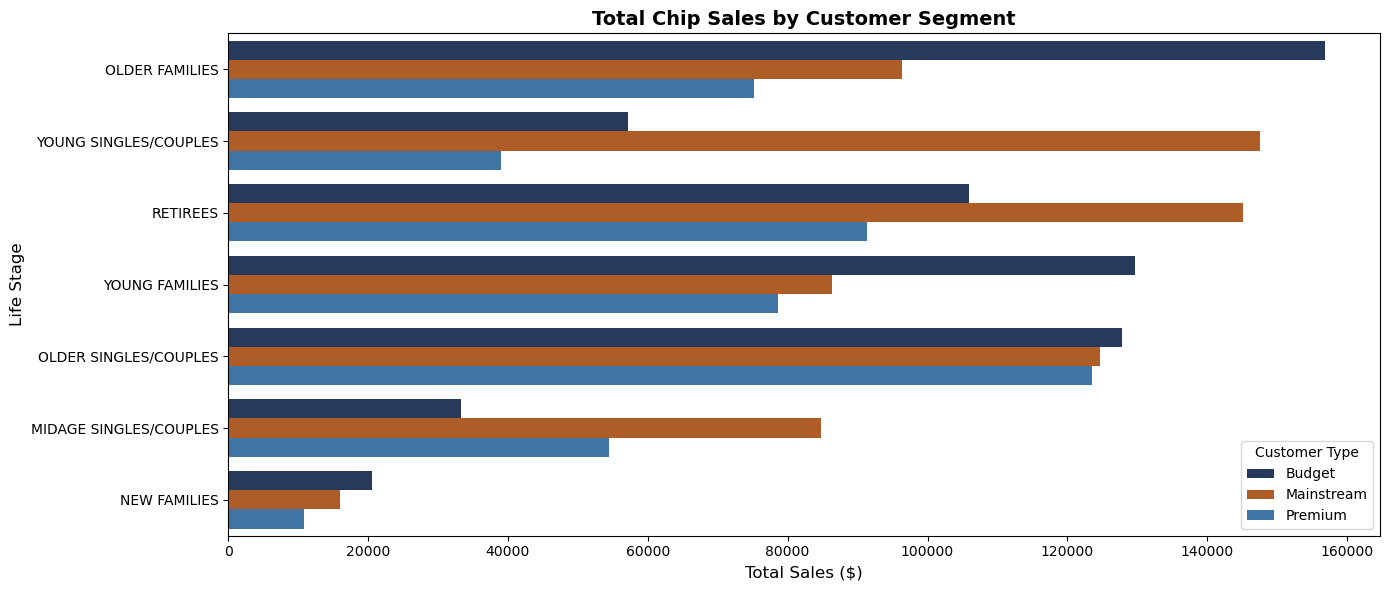

In [27]:
# Create a bar chart of total sales by segment
plt.figure(figsize=(14, 6))

# Create the bar chart
sns.barplot(data=total_sales, 
            x='TOT_SALES', 
            y='LIFESTAGE', 
            hue='PREMIUM_CUSTOMER',
            palette=['#1F3864', '#C45911', '#2E75B6'])

# Add titles and labels
plt.title('Total Chip Sales by Customer Segment', fontsize=14, fontweight='bold')
plt.xlabel('Total Sales ($)', fontsize=12)
plt.ylabel('Life Stage', fontsize=12)
plt.legend(title='Customer Type')
plt.tight_layout()
plt.show()

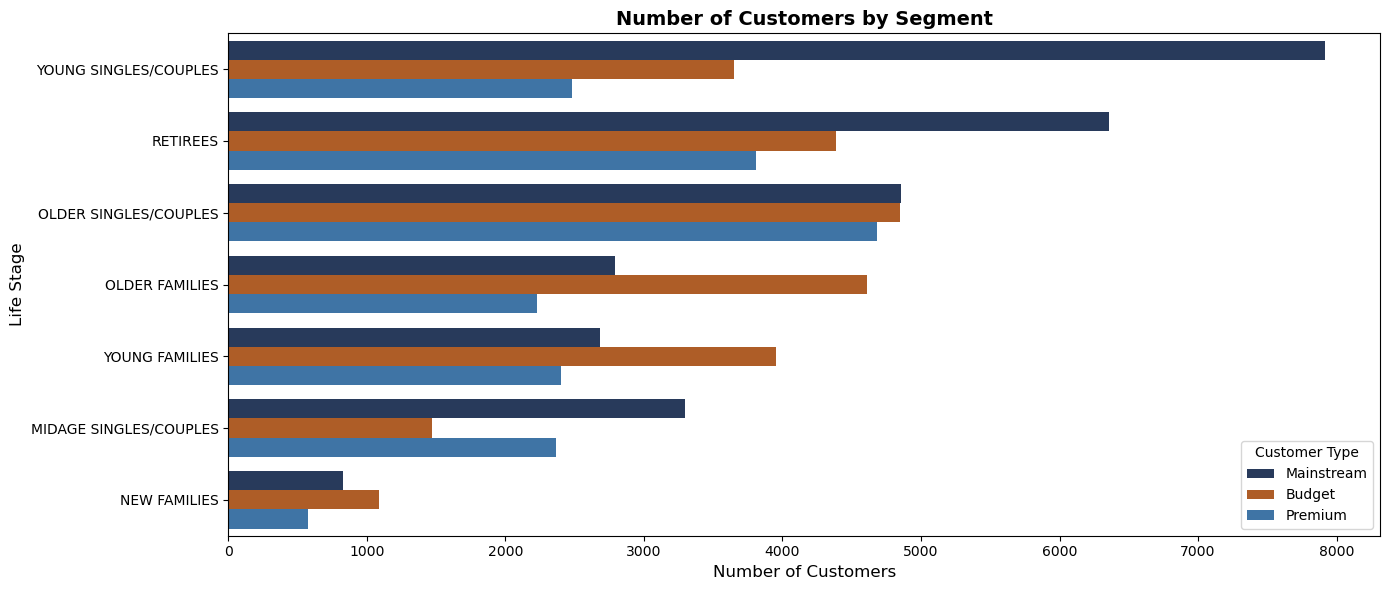

In [28]:
# Number of unique customers by segment
num_customers = data.groupby(['LIFESTAGE', 'PREMIUM_CUSTOMER'])['LYLTY_CARD_NBR'].nunique().reset_index()
num_customers.columns = ['LIFESTAGE', 'PREMIUM_CUSTOMER', 'NUM_CUSTOMERS']
num_customers = num_customers.sort_values('NUM_CUSTOMERS', ascending=False)

plt.figure(figsize=(14, 6))
sns.barplot(data=num_customers,
            x='NUM_CUSTOMERS',
            y='LIFESTAGE',
            hue='PREMIUM_CUSTOMER',
            palette=['#1F3864', '#C45911', '#2E75B6'])

plt.title('Number of Customers by Segment', fontsize=14, fontweight='bold')
plt.xlabel('Number of Customers', fontsize=12)
plt.ylabel('Life Stage', fontsize=12)
plt.legend(title='Customer Type')
plt.tight_layout()
plt.show()

C:\Users\konge\AppData\Local\Temp\ipykernel_17108\1828860658.py:2: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  avg_units = data.groupby(['LIFESTAGE', 'PREMIUM_CUSTOMER']).apply(


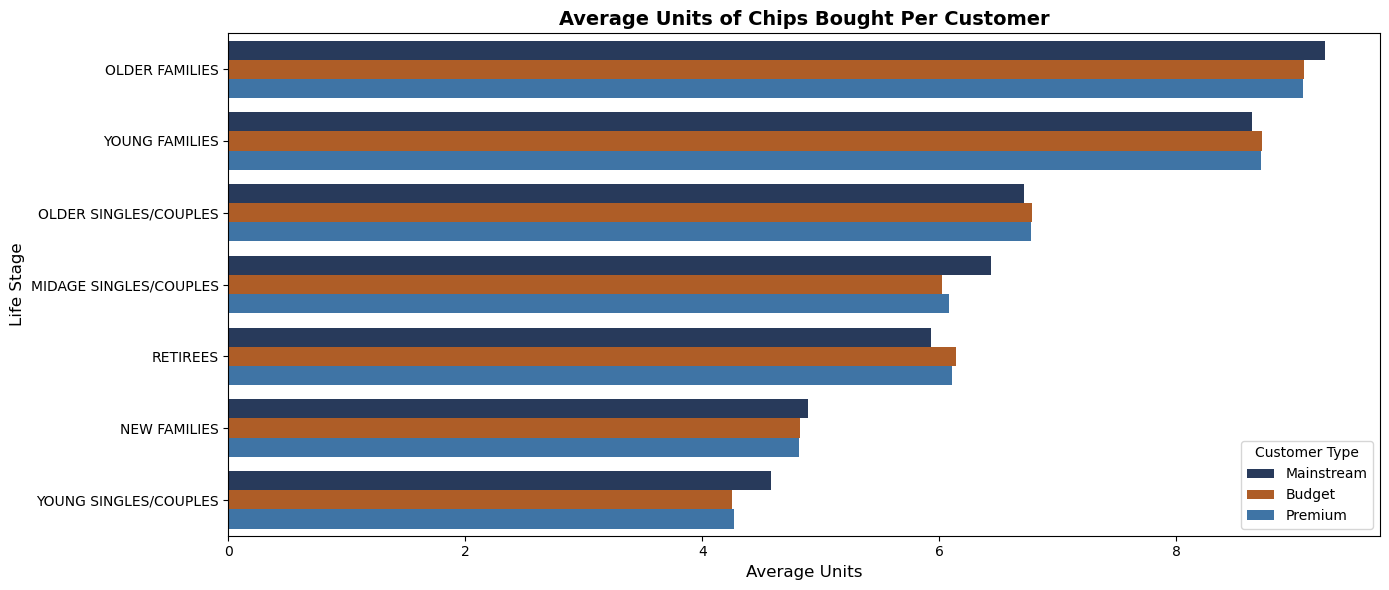

In [29]:
# Average units per customer by segment
avg_units = data.groupby(['LIFESTAGE', 'PREMIUM_CUSTOMER']).apply(
    lambda x: x['PROD_QTY'].sum() / x['LYLTY_CARD_NBR'].nunique()
).reset_index()
avg_units.columns = ['LIFESTAGE', 'PREMIUM_CUSTOMER', 'AVG_UNITS']
avg_units = avg_units.sort_values('AVG_UNITS', ascending=False)

plt.figure(figsize=(14, 6))
sns.barplot(data=avg_units,
            x='AVG_UNITS',
            y='LIFESTAGE',
            hue='PREMIUM_CUSTOMER',
            palette=['#1F3864', '#C45911', '#2E75B6'])

plt.title('Average Units of Chips Bought Per Customer', fontsize=14, fontweight='bold')
plt.xlabel('Average Units', fontsize=12)
plt.ylabel('Life Stage', fontsize=12)
plt.legend(title='Customer Type')
plt.tight_layout()
plt.show()

C:\Users\konge\AppData\Local\Temp\ipykernel_17108\1746705729.py:2: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  avg_price = data.groupby(['LIFESTAGE', 'PREMIUM_CUSTOMER']).apply(


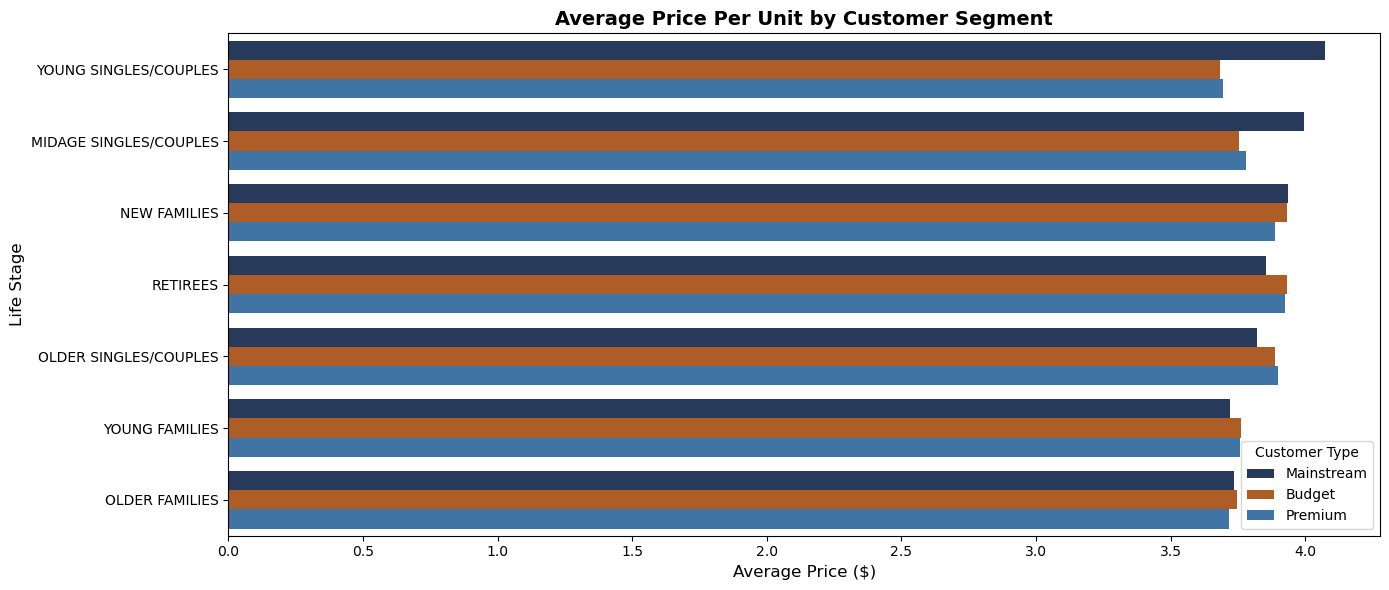

In [30]:
# Average price per unit by segment
avg_price = data.groupby(['LIFESTAGE', 'PREMIUM_CUSTOMER']).apply(
    lambda x: x['TOT_SALES'].sum() / x['PROD_QTY'].sum()
).reset_index()
avg_price.columns = ['LIFESTAGE', 'PREMIUM_CUSTOMER', 'AVG_PRICE']
avg_price = avg_price.sort_values('AVG_PRICE', ascending=False)

plt.figure(figsize=(14, 6))
sns.barplot(data=avg_price,
            x='AVG_PRICE',
            y='LIFESTAGE',
            hue='PREMIUM_CUSTOMER',
            palette=['#1F3864', '#C45911', '#2E75B6'])

plt.title('Average Price Per Unit by Customer Segment', fontsize=14, fontweight='bold')
plt.xlabel('Average Price ($)', fontsize=12)
plt.ylabel('Life Stage', fontsize=12)
plt.legend(title='Customer Type')
plt.tight_layout()
plt.show()

In [31]:
# Deep dive into Mainstream Young Singles/Couples
target = data[(data['LIFESTAGE'] == 'YOUNG SINGLES/COUPLES') & 
              (data['PREMIUM_CUSTOMER'] == 'Mainstream')]

print("Number of transactions from target segment:", len(target))
print("\nTop brands for Mainstream Young Singles/Couples:")
print(target['BRAND'].value_counts().head(10))

Number of transactions from target segment: 19544

Top brands for Mainstream Young Singles/Couples:
BRAND
Kettle       3844
Doritos      2379
Pringles     2315
Smiths       1921
Infuzions    1250
Thins        1166
Twisties      900
Tostitos      890
RRD           875
Cobs          864
Name: count, dtype: int64


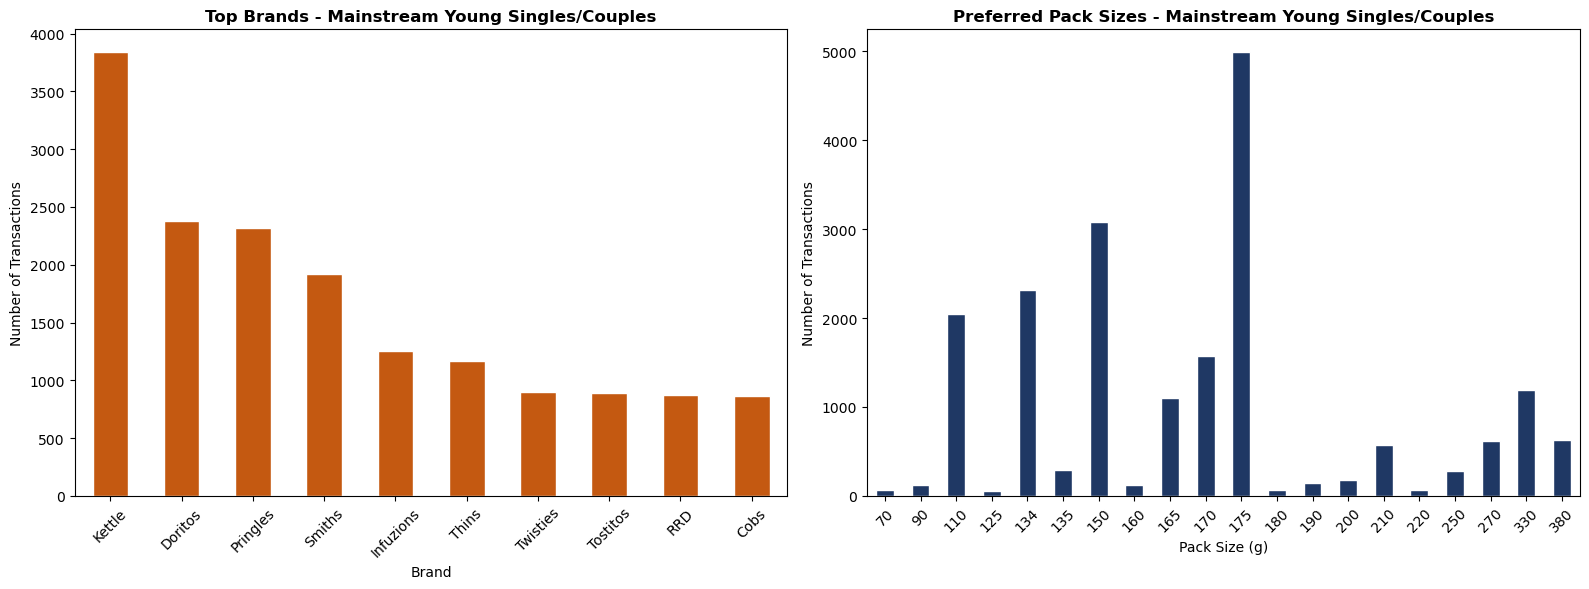

In [32]:
# Create two charts side by side
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Chart 1 - Top brands
target['BRAND'].value_counts().head(10).plot(
    kind='bar', ax=ax1, color='#C45911', edgecolor='white')
ax1.set_title('Top Brands - Mainstream Young Singles/Couples', 
              fontsize=12, fontweight='bold')
ax1.set_xlabel('Brand', fontsize=10)
ax1.set_ylabel('Number of Transactions', fontsize=10)
ax1.tick_params(axis='x', rotation=45)

# Chart 2 - Preferred pack sizes
target['PACK_SIZE'].value_counts().sort_index().plot(
    kind='bar', ax=ax2, color='#1F3864', edgecolor='white')
ax2.set_title('Preferred Pack Sizes - Mainstream Young Singles/Couples', 
              fontsize=12, fontweight='bold')
ax2.set_xlabel('Pack Size (g)', fontsize=10)
ax2.set_ylabel('Number of Transactions', fontsize=10)
ax2.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

In [33]:
# Print our final summary and recommendations
print("""
=== QUANTIUM RETAIL ANALYTICS - TASK 1 FINDINGS ===

DATA CLEANING SUMMARY:
- Removed 18,094 salsa product transactions (not chips)
- Removed 2 transactions from outlier customer (bought 200 packets)
- Fixed DATE column from integer to proper date format
- Standardised 8 inconsistent brand names
- Extracted PACK_SIZE and BRAND from product names
- Final clean dataset: 246,740 transactions

KEY FINDINGS:

1. TOP SPENDING SEGMENT:
   Budget Older Families spend the most on chips overall

2. LARGEST CUSTOMER GROUP:
   Mainstream Young Singles/Couples have the most customers

3. HIGHEST UNITS PER VISIT:
   Older and Young Families buy the most packets per visit

4. HIGHEST PRICE PER UNIT:
   Mainstream Young Singles/Couples pay the most per packet

5. TARGET SEGMENT PREFERENCES:
   Mainstream Young Singles/Couples prefer:
   - Brand: Kettle chips
   - Pack size: 175g

RECOMMENDATIONS FOR JULIA:

1. TARGET Mainstream Young Singles/Couples - they are the 
   largest group AND willing to pay premium prices per unit.
   Focus marketing and shelf placement on this segment.

2. STOCK MORE Kettle 175g chips - this is the most popular 
   combination for the highest value customer segment.

3. RETAIN Budget Older Families - they generate the highest 
   total sales. Ensure competitive pricing and availability 
   of their preferred products.

4. REVIEW Premium segment strategy - Premium customers spend 
   less on chips. Consider whether shelf space allocated to 
   premium chip products is justified.
""")


=== QUANTIUM RETAIL ANALYTICS - TASK 1 FINDINGS ===

DATA CLEANING SUMMARY:
- Removed 18,094 salsa product transactions (not chips)
- Removed 2 transactions from outlier customer (bought 200 packets)
- Fixed DATE column from integer to proper date format
- Standardised 8 inconsistent brand names
- Extracted PACK_SIZE and BRAND from product names
- Final clean dataset: 246,740 transactions

KEY FINDINGS:

1. TOP SPENDING SEGMENT:
   Budget Older Families spend the most on chips overall

2. LARGEST CUSTOMER GROUP:
   Mainstream Young Singles/Couples have the most customers

3. HIGHEST UNITS PER VISIT:
   Older and Young Families buy the most packets per visit

4. HIGHEST PRICE PER UNIT:
   Mainstream Young Singles/Couples pay the most per packet

5. TARGET SEGMENT PREFERENCES:
   Mainstream Young Singles/Couples prefer:
   - Brand: Kettle chips
   - Pack size: 175g

RECOMMENDATIONS FOR JULIA:

1. TARGET Mainstream Young Singles/Couples - they are the 
   largest group AND willing to pay